This notebook focuses on trying to find a way to segment cells properly.
The end goals is to segment cell and extract morphology features from cellprofiler.
These masks must be imported into cellprofiler to extract features.

In [1]:
import argparse
import os
import pathlib

import matplotlib.pyplot as plt
import natsort

# Import dependencies
import numpy as np
import skimage
import tifffile
from cellpose import models
from centrosome.cpmorphology import fill_labeled_holes
from centrosome.propagate import propagate
from PIL import Image
from timelapse_utils.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)

root_dir, in_notebook = init_notebook()
if in_notebook:
    import tqdm.notebook as tqdm
else:
    import tqdm

/home/lippincm/miniforge3/envs/timelapse_segmentation_env/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/lippincm/miniforge3/envs/timelapse_segmentation_env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /home/lippincm/miniforge3/envs/timelapse_segmentation_env/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [ ]:
if not in_notebook:
    # set up arg parser
    parser = argparse.ArgumentParser(description="Segment the nuclei of a tiff image")

    parser.add_argument(
        "--well_fov",
        type=str,
        help="Name of the well and field of view to segment, e.g. B2_1",
    )

    parser.add_argument(
        "--clip_limit",
        type=float,
        help="Clip limit for the adaptive histogram equalization",
    )

    parser.add_argument(
        "--plate_name",
        type=str,
        help="Name of the plate to process",
    )

    args = parser.parse_args()
    clip_limit = args.clip_limit
    well_fov = args.well_fov
    plate_name = args.plate_name

else:
    well_fov = "B2_1"
    clip_limit = 0.3
    plate_name = "plate_2"


image_base_dir = bandicoot_check(
    root_dir=root_dir,
    bandicoot_mount_path=pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(),
)

input_dir = pathlib.Path(
    image_base_dir / "processed_data" / "0.renamed_files" / plate_name / well_fov
).resolve(strict=True)

segmentation_mask_output_dir = pathlib.Path(
    image_base_dir
    / "processed_data"
    / "2.cell_segmentation_masks"
    / plate_name
    / well_fov
).resolve()
segmentation_mask_output_dir.mkdir(exist_ok=True, parents=True)

figures_dir = pathlib.Path("../figures").resolve()
figures_dir.mkdir(exist_ok=True, parents=True)

## Set up images, paths and functions

In [3]:
image_extensions = {".tif", ".tiff"}
raw_image_files = sorted(input_dir.glob("*"))
raw_image_files = [str(x) for x in raw_image_files if x.suffix in image_extensions]
raw_image_files = natsort.natsorted(raw_image_files)

mask_image_files = sorted(segmentation_mask_output_dir.glob("*"))
mask_image_files = [str(x) for x in mask_image_files if x.suffix in image_extensions]
mask_image_files = natsort.natsorted(mask_image_files)

In [4]:
input_dict = {
    "well_fov": [],
    "time_point": [],
    "raw_image_path": [],
    "nuclei_mask_path": [],
}

input_dict["time_point"] = [
    pathlib.Path(file).stem.split("_")[2]
    for file in raw_image_files
    if "C2" in pathlib.Path(file).stem.split("_")[3]
]
input_dict["raw_image_path"] = [
    pathlib.Path(file)
    for file in raw_image_files
    if "C2" in pathlib.Path(file).stem.split("_")[3]
]
input_dict["nuclei_mask_path"] = [
    pathlib.Path(file) for file in mask_image_files if "nuclei_mask" in file
]
input_dict["well_fov"] = [well_fov] * len(input_dict["nuclei_mask_path"])

In [8]:
for i, (
    well_fov,
    time_point,
    single_cyto_image_path,
    single_nuclei_mask_path,
) in tqdm.tqdm(
    enumerate(
        zip(
            input_dict["well_fov"],
            input_dict["time_point"],
            input_dict["raw_image_path"],
            input_dict["nuclei_mask_path"],
        )
    ),
    total=len(input_dict["well_fov"]),
):
    output_path = (
        segmentation_mask_output_dir / f"{well_fov}_{time_point}_cell_mask.tiff"
    )
    # if output_path.exists():
    #     continue

    single_cyto_image = tifffile.imread(single_cyto_image_path)
    single_nuclei_mask = tifffile.imread(single_nuclei_mask_path)
    # clip limit the cytoplasm image to enhance the contrast of the cytoplasm regions
    single_cyto_image = skimage.exposure.equalize_adapthist(
        single_cyto_image, clip_limit=clip_limit
    )
    # set the thresholds for multi-otsu segmentation
    thresholds = skimage.filters.threshold_multiotsu(
        image=single_cyto_image,
        classes=3,
    )
    # retrieve the foreground regions defined by Otsu
    foreground = np.digitize(single_cyto_image, bins=thresholds) == 2

    # segment the cells using propagation with the nuclei mask as markers and the Otsu-defined foreground as the mask
    cell_mask, _ = propagate(
        image=single_cyto_image,
        labels=single_nuclei_mask,
        mask=foreground,  # only propagate within the foreground regions defined by Otsu
        weight=0.5  # weight parameter to control the influence of the image intensity on the propagation.
        # A higher weight means that the propagation will be more influenced by the image intensity,
        # while a lower weight means that the propagation will be more influenced by the labels.
    )
    # fill any holes in the cell mask that are within the foreground regions defined by propagation
    cell_mask = fill_labeled_holes(cell_mask, mask=cell_mask == 0)

    # Save the segmented mask as a tiff file
    tifffile.imwrite(output_path, cell_mask.astype(np.uint16))

    # verify that the nuclei mask and cell mask have the same number of unique labels
    nuclei_labels = np.unique(single_nuclei_mask)
    cell_labels = np.unique(cell_mask)
    set_difference = set(nuclei_labels) - set(cell_labels)
    #############################################################
    # NOTE This should never print ever
    # This is a HUGE red flag that something is wrong with the segmentation.
    # If this prints, it means that there are nuclei that were not assigned to any cell in the cell mask.
    # This could be due to a bug in the code, or it could be due to a problem with the input images (e.g., if the nuclei are not well-separated from each other or from the background).
    # If this happens, you should investigate the input images and the segmentation results to determine the cause of the problem.
    #############################################################
    if len(set_difference) > 0:
        print(
            f"Warning: The nuclei mask and cell mask have different unique labels for {well_fov} at {time_point}. The following labels are in the nuclei mask but not in the cell mask: {set_difference}"
        )

  0%|          | 0/12 [00:00<?, ?it/s]

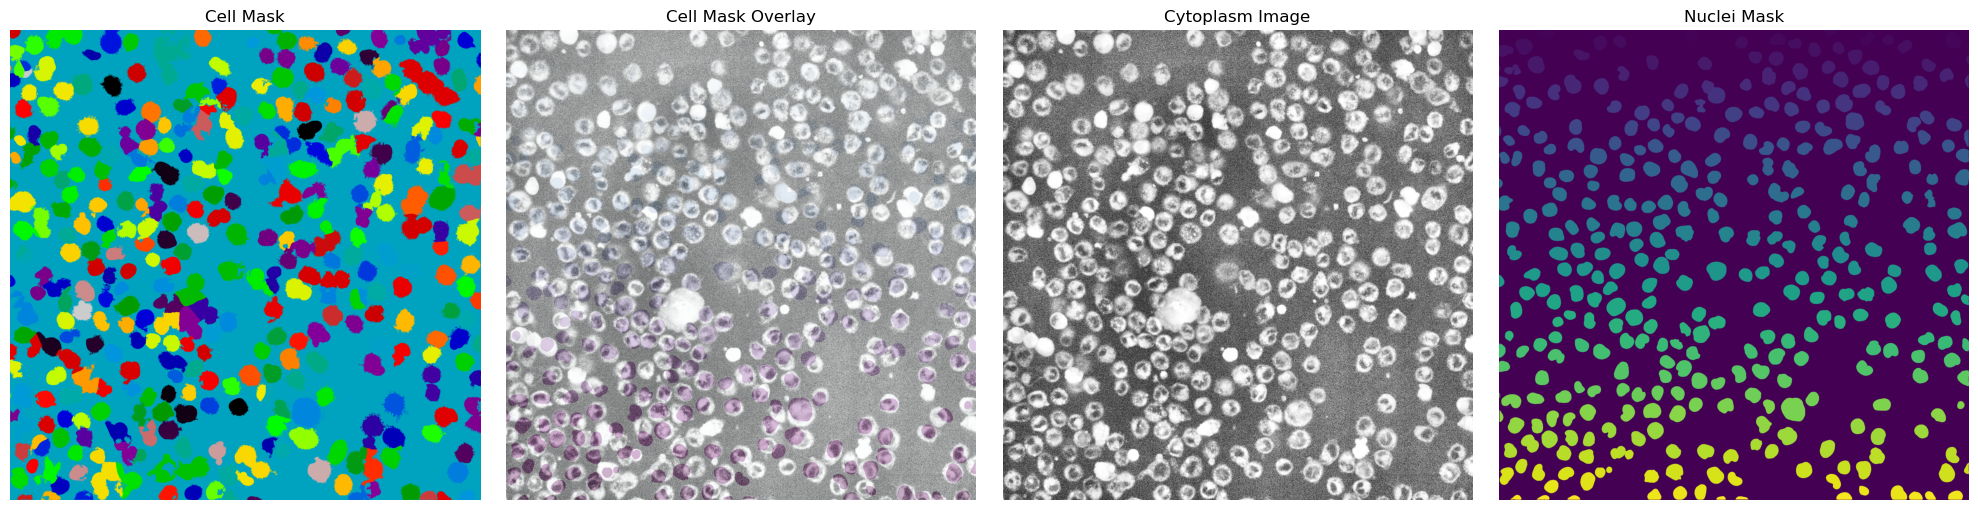

In [9]:
if in_notebook:
    # randomize the label ids in the cell mask
    unique_labels = np.unique(cell_mask)
    randomized_labels = np.random.permutation(unique_labels)
    randomized_cell_mask = np.zeros_like(cell_mask)
    for original, randomized in zip(unique_labels, randomized_labels):
        randomized_cell_mask[cell_mask == original] = randomized
    cell_mask = randomized_cell_mask
    # set the largest label to 0 (background)
    largest_label = np.max(cell_mask)
    cell_mask[cell_mask == largest_label] = 0
    # get mask outlines
    # outlines = skimage.segmentation.find_boundaries(cell_mask, mode="outer")

    plt.figure(figsize=(20, 5))
    plt.subplot(141)
    plt.imshow(cell_mask, cmap="nipy_spectral")
    plt.title("Cell Mask")
    plt.axis("off")
    # overlay the nuclei mask on the cyto image

    plt.subplot(142)
    plt.title("Cell Mask Overlay")
    plt.imshow(
        single_nuclei_mask,
        cmap="BuPu",
    )
    plt.imshow(
        single_cyto_image,
        cmap="gray",
        vmin=0,
        vmax=np.percentile(single_cyto_image, 98),
        alpha=0.7,
    )

    plt.axis("off")
    plt.subplot(143)
    plt.imshow(
        single_cyto_image,
        cmap="gray",
        vmin=0,
        vmax=np.percentile(single_cyto_image, 99),
    )
    plt.title("Cytoplasm Image")
    plt.axis("off")
    plt.subplot(144)
    plt.imshow(single_nuclei_mask, cmap="viridis")
    plt.title("Nuclei Mask")
    plt.axis("off")
    plt.tight_layout()
    plt.show()